# Imports der Bibliotheken

In [1]:
#Masterprojekt SFH - 1 Verbraucher, 1 Wärmepumpe, 1 Speicher
import logging
logger = logging.getLogger("gurobipy")
logger.propagate = False

import pandas as pd
import pypsaheat as ph
import pypsa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Einlesen Lastgänge & Zuordnung der Daten

In [2]:
#Einlesen der Lastgänge
input_data = pd.read_csv('Inputs/MasterProjekt_Lastprofile.csv', index_col=0)
input_data

#limitieren der Daten auf 3 Wochen
start = 0      # 0 = Anfang des Jahres
input_data = input_data.iloc[start : start + 504]
input_data.index = range(len(input_data)) 

In [3]:
input_data = input_data.drop(columns=["Waerme gesamt (kW)"]).rename(
    columns={"Temp C": "temp","Zone 2-Trinkwarmwasser (kW)": "heat_water","Zone 2-Raumwaerme (kW)": "heat_space",}
)

print(input_data.columns)
input_data = input_data[["temp", "heat_water", "heat_space"]]
input_data.index.name = "index"
input_data.to_csv("Inputs/load_profile_3_weeks.csv", index=True)

Index(['heat_space', 'heat_water', 'temp'], dtype='object')


In [4]:
input_data

,temp,heat_water,heat_space
index,,,
0,6.286,0.2,1.7
1,5.997,0.1,1.7
2,5.705,0.1,1.8
3,5.534,0.0,1.7
4,5.451,0.1,1.8
...,...,...,...
499,-4.842,0.8,5.8
500,-5.690,0.7,5.8
501,-6.235,0.6,5.6


<Axes: xlabel='index'>

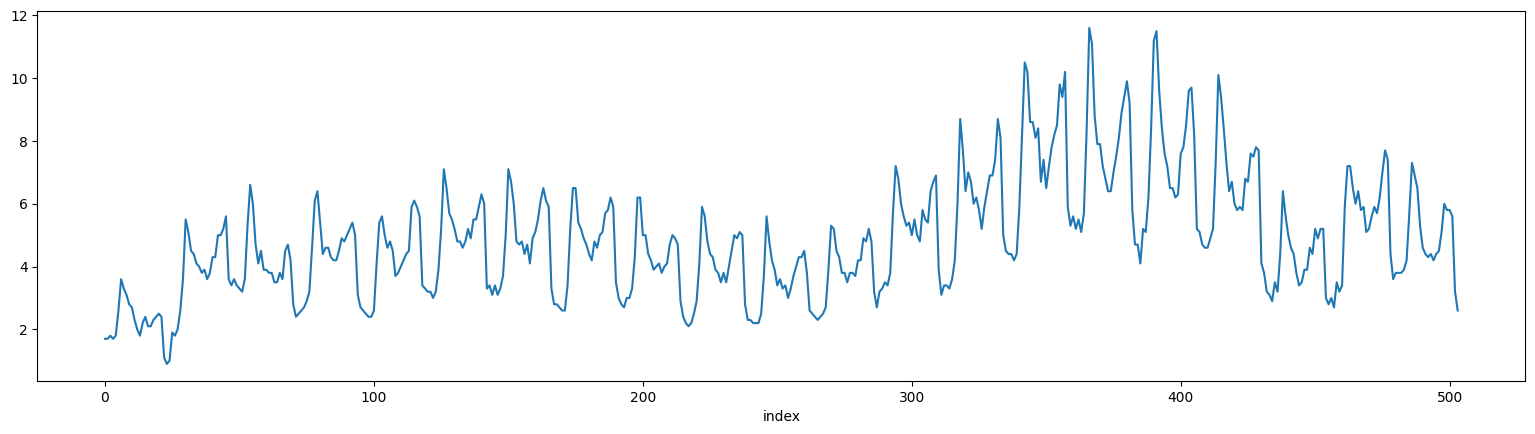

In [5]:
#Zuordnung der Daten aus den Lastgängen
raumwaerme = input_data['heat_space'] #Heizlast von SFH in kW
raumwaerme.plot(figsize=(19.2, 4.8))

<Axes: xlabel='index'>

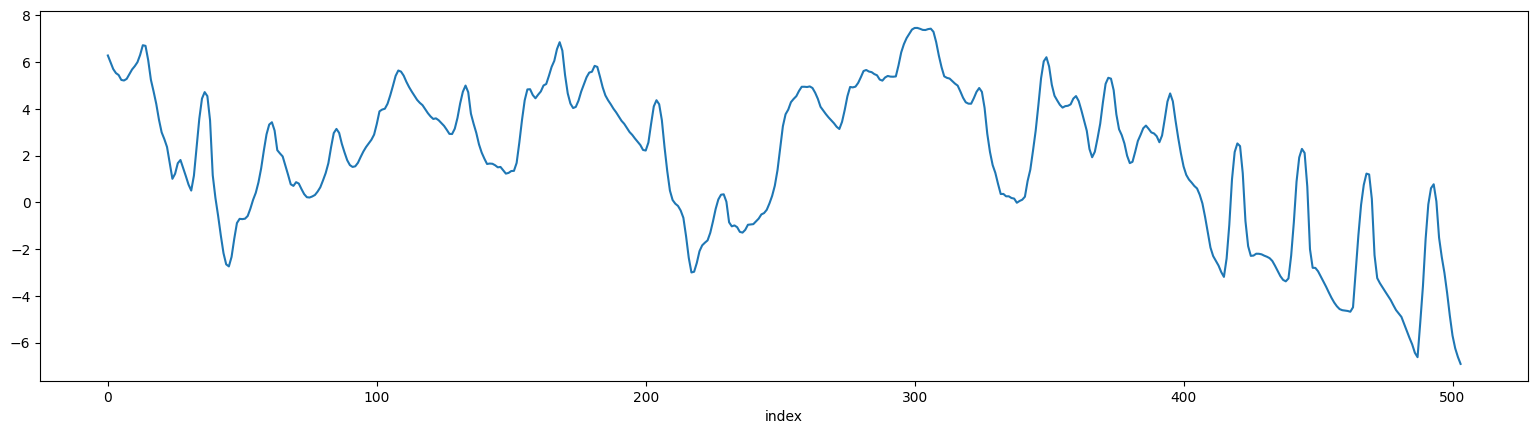

In [6]:
# aussentemperatur = df_data_weather['DE_temperature']
aussentemperatur = input_data['temp']
aussentemperatur.plot(figsize=(19.2, 4.8))

# System Eigenschaften

In [7]:
#Wärmespeicher Eigenschaften 
Store_height = 2 #m
Store_base = 0.8 #m²
V_layer = (Store_height * Store_base) / 3

T_Warmwasser = 55

#Wärmepumpen Leistung
HP_power = 20 #kW Wärmepumpenleistung

#Strom
grid_cost = 0.35 # €/kWh Kosten für Netzstrombezug
grid_power = 50 #kW Hausanschluss Leistung

In [8]:
V_layer

0.5333333333333333

<Axes: xlabel='index'>

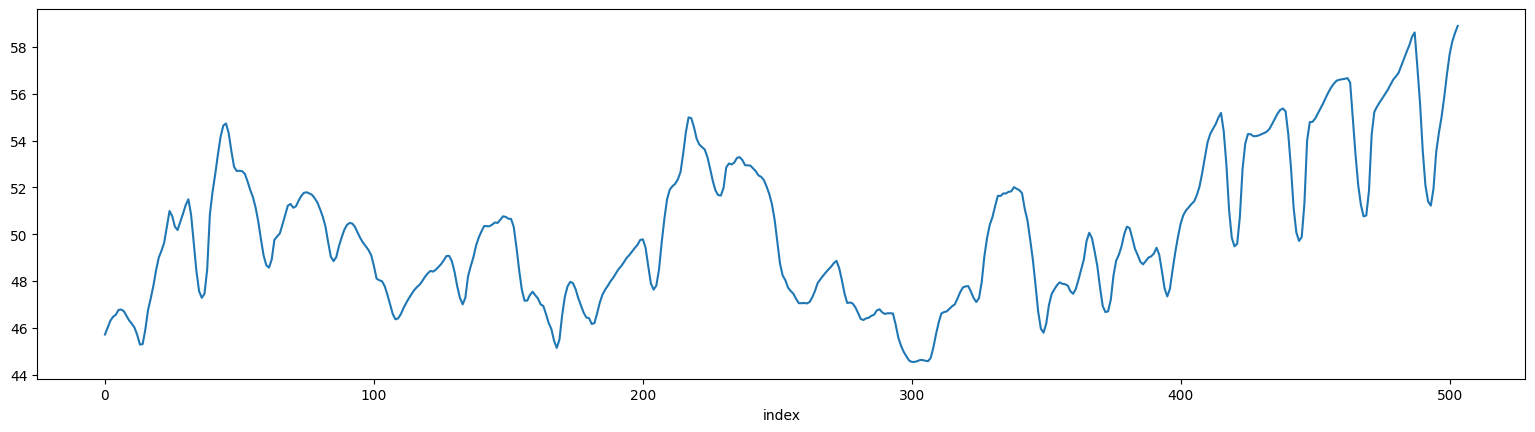

In [9]:
# Vorlauftemperatur für Heizsystem
T_at_0 = 52  #°C Vorlauftemperatur bei Außentemperatur 0°C
T_gradient = 1  #°C/°C Steigung der Heizkurve

T_flow = ph.physics.flow_temperature(T_at_0, T_gradient, aussentemperatur)
T_flow.plot(figsize=(19.2, 4.8))

In [10]:
# Berechnung der Rücklauftemperatur
T_flow_return = pd.Series([40] * len(input_data))
T_flow_return

0      40
1      40
2      40
3      40
4      40
       ..
499    40
500    40
501    40
502    40
503    40
Length: 504, dtype: int64

# Modellerstellung

In [11]:
# Aufbau des Modells
n = ph.HeatNetwork()
n.set_snapshots(input_data.index)

n.add("Bus",  
      name = "electricity"      
)

n.add('Generator',
      bus = 'electricity',
      name = 'grid',
      p_nom = grid_power,
      marginal_cost = grid_cost
  )

n.add('Load', 
      bus = 'electricity', 
      name = 'Elektrische Last'
)

# Hinzufügen der Raumwärmelast
n.add('HeatLoad',
      name = 'heat_space_demand',
      heat_store = 'hs',
      p_set = input_data['heat_space'],
      T_demand = T_flow
      )

# Hinzufügen eines Schichtspeichers mit konstanten Volumschichten
n.add('HeatStore',
      name='hs',
      constant='temperature',  # konstante Temperatur in den Schichten
      height=Store_height,
      base=Store_base,      
      cyclic=False,
      U_wall=0.15,
      V_initial = [V_layer, V_layer, V_layer],  # Volumen in den Schichten m³                 
      T_layer = [60,55,50],  # Beispieltemperaturen für die Schichten
      T_return = T_flow_return # Rücklauftemperatur des Heizsystems, °C
)

# Hinzufügen einer Wärmepumpe an den Wärmespeicher
n.add('HeatPump',
      name = 'hp',
      bus0 = 'electricity',
      p_nom = HP_power,
      heat_store = 'hs',
      T_source = input_data['temp'],
      T_max = 65,        # max. lieferbare Temperatur der WP
      #T_sink = T_at_0,  
      heat_source = 'air'
)

In [12]:
n.heat_loads

attribute,heat_store,carrier,type,p_set,T_demand,T_diff_return,internal_exchange,outlet_height,inlet_height
HeatLoad,,,,,,,,,
heat_space_demand,hs,,,0.0,50.0,10.0,False,1.0,0.0


# Optimierung

In [13]:
n.heat_stores_t

{'T_amb': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
 
 [504 rows x 0 columns],
 'T_return': HeatStore    hs
 snapshot       
 0          40.0
 1          40.0
 2          40.0
 3          40.0
 4          40.0
 ...         ...
 499        40.0
 500        40.0
 501        40.0
 502        40.0
 503        40.0
 
 [504 rows x 1 columns],
 'T': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 

In [14]:
n.optimize(solver_name = 'gurobi')

Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username
Set parameter LicenseID to value 2756558
Academic license - for non-commercial use only - expires 2026-12-18


INFO:linopy.io: Writing time: 0.05s


Read LP format model from file C:\Users\robin\AppData\Local\Temp\linopy-problem-j01wtlxn.lp
Reading time = 0.02 seconds
obj: 12096 rows, 5040 columns, 21669 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 5 245K, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 12096 rows, 5040 columns and 21669 nonzeros
Model fingerprint: 0x3ea479c0
Coefficient statistics:
  Matrix range     [4e-01, 2e+01]
  Objective range  [3e-01, 3e-01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e-03, 5e+01]
Presolve removed 9579 rows and 1011 columns
Presolve time: 0.01s
Presolved: 2517 rows, 4029 columns, 9574 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   3.375413e+02   0.000000e+00      0s
    3269    3.6847047e+02   0.000000e+00   0.000000e+00      0s

Solved in 3269 iterations and 

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 5040 primals, 12096 duals
Objective: 3.68e+02
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, HeatStore-hs-fix-volume-upper, HeatStore-hs-fix-volume-lower, HeatStore-hs-fix-layer-upper, HeatStore-hs-layer_balance, HeatStore-hs-internal-lower, HeatPump-hp-fix-p-lower, HeatPump-hp-fix-p-upper, HeatPump-hp-fix-p-layer-lower, HeatPump-hp-fix-p-layer-upper were not assigned to the network.


PyPSA Heat Network
Components:
 - Bus: 1
 - Generator: 1
 - HeatLoad: 1
 - HeatPump: 1
 - HeatStore: 1
 - Load: 1
 - HeatLoad: 1
 - HeatPump: 1
 - HeatStore: 1
Snapshots: 504

In [15]:
n.heat_pumps_t

{'T_source':              hp
 snapshot       
 0         6.286
 1         5.997
 2         5.705
 3         5.534
 4         5.451
 ...         ...
 499      -4.842
 500      -5.690
 501      -6.235
 502      -6.605
 503      -6.903
 
 [504 rows x 1 columns],
 'T_nom': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
 
 [504 rows x 0 columns],
 'p_min_pu': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 5

In [16]:
heatstore_daten=n.heat_stores_t.T

In [17]:
n.heat_stores_t

{'T_amb': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
 
 [504 rows x 0 columns],
 'T_return': HeatStore    hs
 snapshot       
 0          40.0
 1          40.0
 2          40.0
 3          40.0
 4          40.0
 ...         ...
 499        40.0
 500        40.0
 501        40.0
 502        40.0
 503        40.0
 
 [504 rows x 1 columns],
 'T': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 

# Python Ergebnisse

In [18]:
#ph.plot.plot_stratified_heat_store(n, 'hs', sns = n.snapshots)

In [19]:
#Zuordnung der Ergebnisse aus dem Modell
#WP-Daten und Schichtdaten
v_hs_60 = n.heat_stores_t.V.iloc[:, 0]
v_hs_55 = n.heat_stores_t.V.iloc[:, 1]
v_hs_50 = n.heat_stores_t.V.iloc[:, 2]
T_return = n.heat_stores_t.T_return


p_elec = n.heat_pumps_t.p_elec
p_heat = n.heat_pumps_t.p_heat
COP = n.heat_pumps_t.COP
p_hp_60 = p_heat[('hp', 60)]
p_hp_55 = p_heat[('hp', 55)]
p_hp_50 = p_heat[('hp', 50)]

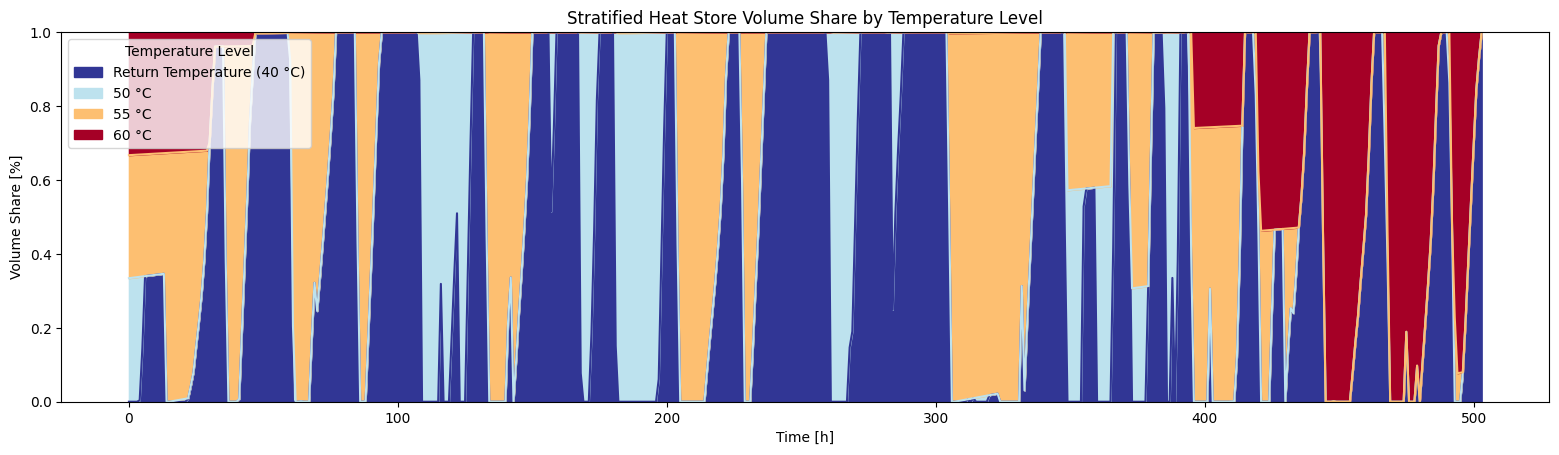

In [20]:
df = n.heat_stores_t.V.clip(lower=0)
df.insert(3, 'Return Temperature (40 °C)', ((Store_base * Store_height) - df.sum(axis=1)).clip(lower=0))
df.columns = ['60 °C', '55 °C', '50 °C', 'Return Temperature (40 °C)']
df = df.iloc[:, ::-1]

# Rescale volume to share (0 to 1) by dividing by total store capacity
df_share = df.div(Store_base * Store_height, axis=0)

ax = df_share.plot(kind='area', stacked=True, figsize=(19.2, 4.8), cmap='RdYlBu_r')
ax.set_title("Stratified Heat Store Volume Share by Temperature Level")
ax.set_xlabel("Time [h]")
ax.set_ylabel("Volume Share [%]")
ax.set_ylim(0, 1)
ax.legend(title="Temperature Level", loc='upper left', bbox_to_anchor=(0, 1))

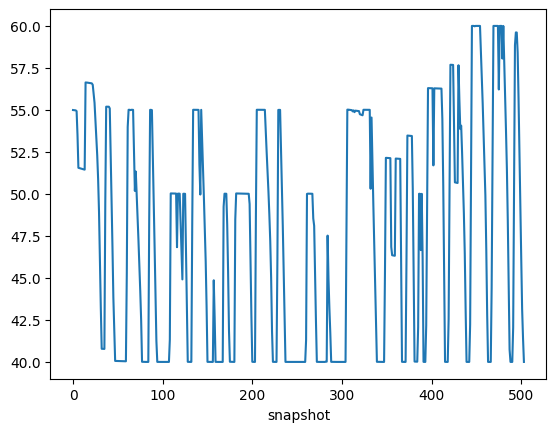

In [21]:
df = n.heat_stores_t.V.clip(lower=0)
df.columns = ['60 °C', '55 °C', '50 °C']
df.insert(3, 'Rücklauf (40 °C)', ((Store_base * Store_height) - df.sum(axis=1)).clip(lower=0))

temperaturen = [60, 55, 50, 40]
gesamtvolumen = Store_base * Store_height

py_hs_T_avg = (df * temperaturen).sum(axis=1) / gesamtvolumen
py_hs_T_avg.plot();

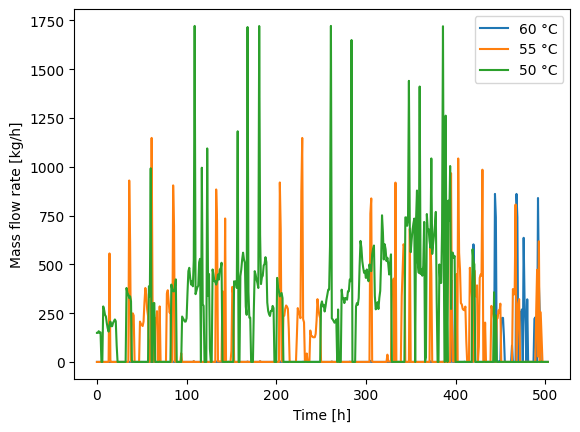

In [22]:
# Berechnung der Massenströme pro Schicht
m_hs_60 = p_hp_60 / ((0.001161388889) * (60 - T_return.hs))
m_hs_55 = p_hp_55 / ((0.001161388889) * (55 - T_return.hs))
m_hs_50 = p_hp_50 / ((0.001161388889) * (50 - T_return.hs))

ax = m_hs_60.plot(label="60 °C")
m_hs_55.plot(ax=ax, label="55 °C")
m_hs_50.plot(ax=ax, label="50 °C")
ax.legend()
ax.set_ylabel("Mass flow rate [kg/h]")
ax.set_xlabel("Time [h]")

m_hs_total = m_hs_60.add(m_hs_55, fill_value=0).add(m_hs_50, fill_value=0)

In [23]:
# Berechnung der Kosten für den Netzbezug durch die Wärmepumpe
cost_grid = p_elec * grid_cost
total_cost_grid = cost_grid.sum().sum()

print(f"Kosten Netzbezug durch WP: {total_cost_grid:.2f} €")

Kosten Netzbezug durch WP: 368.47 €


# CSV-Ausgabe

In [ ]:
# Kombinierten DataFrame erstellen
output_pypsa = pd.DataFrame({
    'py_P_elec': p_elec.hp,
    'py_P_heat_60': p_heat[('hp', 60)],
    'py_P_heat_55': p_heat[('hp', 55)],
    'py_P_heat_50': p_heat[('hp', 50)],
    'py_m_hs_60': m_hs_60,
    'py_m_hs_55': m_hs_55,
    'py_m_hs_50': m_hs_50,
    'py_COP_60': COP[('hp', 60)],
    'py_COP_55': COP[('hp', 55)],
    'py_COP_50': COP[('hp', 50)],
    'py_V_60': v_hs_60,
    'py_V_55': v_hs_55,
    'py_V_50': v_hs_50,
    'py_V_total':  v_hs_60 + v_hs_55 + v_hs_50,
    'py_T_return': T_return.hs,
    'py_P_heat_total': p_heat[('hp', 60)] + p_heat[('hp', 55)] + p_heat[('hp', 50)],
    'm_ges': m_hs_total,
    'py_T_m': py_hs_T_avg
})

output_pypsa.to_csv(
    "Outputs/konstanterTemperaturspeicher/output_pypsa.csv",
    sep=",",
    index_label="index",     
)

In [25]:
output_pypsa

,py_P_elec,py_P_heat_60,py_P_heat_55,py_P_heat_50,py_m_hs_60,py_m_hs_55,py_m_hs_50,py_COP_60,py_COP_55,py_COP_50,py_V_60,py_V_55,py_V_50,py_V_total,py_T_return,py_P_heat_total,m_ges,T_avg
snapshot,,,,,,,,,,,,,,,,,,
0,0.635708,0.0,0.0,1.729125,0.0,0.0,148.884277,2.13,2.41,2.72,0.532650,0.532537,0.534813,1.600000,40.0,1.729125,148.884277,54.993241
1,0.638056,0.0,0.0,1.729133,0.0,0.0,148.884898,2.11,2.39,2.71,0.531968,0.531741,0.536291,1.600000,40.0,1.729133,148.884898,54.986489
2,0.679978,0.0,0.0,1.829140,0.0,0.0,157.495890,2.10,2.38,2.69,0.531286,0.530946,0.537768,1.600000,40.0,1.829140,157.495890,54.979744
3,0.645204,0.0,0.0,1.729147,0.0,0.0,148.886138,2.09,2.37,2.68,0.530605,0.530152,0.539243,1.600000,40.0,1.729147,148.886138,54.973007
4,0.659012,0.0,0.0,1.759561,0.0,0.0,151.504930,2.08,2.36,2.67,0.529925,0.529359,0.534733,1.594017,40.0,1.759561,151.504930,54.928883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.61,1.83,2.07,0.741918,0.000644,0.000829,0.743390,40.0,0.000000,0.000000,49.285189
500,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.58,1.79,2.03,0.491576,0.000483,0.000621,0.492679,40.0,0.000000,0.000000,46.153103
501,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.56,1.76,2.00,0.250091,0.000322,0.000414,0.250827,40.0,0.000000,0.000000,43.131742


# TRNSYS Ergebnisse

In [ ]:
TRNSYSinputs = [
    "Inputs/TRNSYS/Temperatur/TRNSYSMassenstromHausseitig3weeks.csv",
    "Inputs/TRNSYS/Temperatur/TRNSYSRaumwärmebedarf3weeks.csv",
    #"Inputs/TRNSYS/TRNSYSRücklauftemperaturKonstanterTemperaturspeicher.csv",
    "Inputs/TRNSYS/Temperatur/TRNSYSspeichermitteltemperatur3weeks.csv",
    #"Inputs/TRNSYS/TRNSYSspeicherschichttemperaturen.csv",
    "Inputs/TRNSYS/Temperatur/TRNSYSWärmepumpe3weeks.csv",
]

df_liste = []

for f in TRNSYSinputs:
    df = pd.read_csv(f, encoding='latin1', skipinitialspace=True, engine='python', quoting=3, sep=',')
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    
    if 'TIME' in df.columns:
        df = df[pd.to_numeric(df['TIME'], errors='coerce').notnull()]
        df = df.apply(pd.to_numeric, errors='coerce')
        df['TIME'] = df['TIME'].round(2)
        df = df.set_index('TIME')
    
    df_liste.append(df)

TRNSYSdata = pd.concat(df_liste, axis=1).sort_index().reset_index()
TRNSYSdata = TRNSYSdata.rename(columns={'TIME':'Time', 'Massenstrom':'ts_m_heatspace', 'T_amb':'ts_T_amb', 'P_heatspace':'ts_P_heatspace', 'T_R':'ts_T_R', 'T_M':'ts_T_m', 'T_1':'ts_T_1', 'T_2':'ts_T_2','T_3':'ts_T_3', 'p_heat':'ts_P_heat', 'm_flow':'ts_m_flow'})
TRNSYSdata = TRNSYSdata.round(6)
TRNSYSdata

In [ ]:
plt.figure(figsize=(19.2, 4.8))

plt.plot(output_pypsa["py_T_m"].fillna(0), label="$T_m$ PyPSA_heat", color="red")
plt.plot(TRNSYSdata["ts_T_m"].fillna(0), label="$T_m$ TRNSYS", color="dodgerblue")


plt.ylim(39, 61)
plt.xlabel("Time [h]")
plt.ylabel("Temperature [°C]")
plt.title("Comparison: Average Storage Temperature")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()

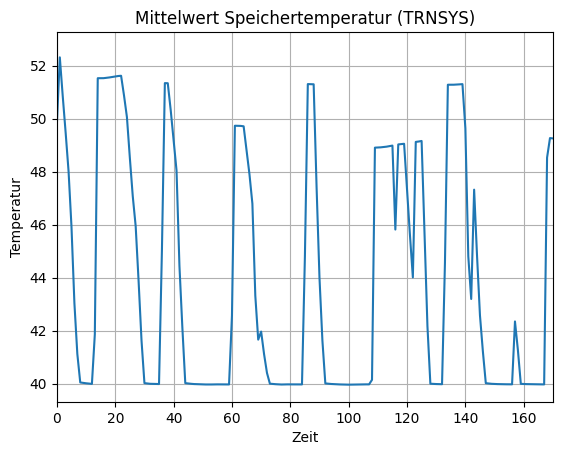

In [28]:
TRNSYS_T_m = TRNSYSdata['ts_T_m'].copy()

TRNSYS_T_m.plot()
plt.title('Mittelwert Speichertemperatur (TRNSYS)')
plt.xlabel('Zeit')
plt.ylabel('Temperatur')
plt.xlim(0, 170)
plt.grid()
plt.savefig('Outputs/konstanterTemperaturspeicher/ts_speicherschichten_m.png')
plt.show()

In [29]:
output_combined = pd.concat([output_pypsa, TRNSYSdata], axis=1)
output_combined

,py_P_elec,py_P_heat_60,py_P_heat_55,py_P_heat_50,py_m_hs_60,py_m_hs_55,py_m_hs_50,py_COP_60,py_COP_55,py_COP_50,py_V_60,py_V_55,py_V_50,py_V_total,py_T_return,py_P_heat_total,m_ges,T_avg,Time,ts_T_m
0,0.635708,0.0,0.0,1.729125,0.0,0.0,148.884277,2.13,2.41,2.72,0.532650,0.532537,0.534813,1.600000,40.0,1.729125,148.884277,54.993241,0.0,49.829000
1,0.638056,0.0,0.0,1.729133,0.0,0.0,148.884898,2.11,2.39,2.71,0.531968,0.531741,0.536291,1.600000,40.0,1.729133,148.884898,54.986489,1.0,52.317432
2,0.679978,0.0,0.0,1.829140,0.0,0.0,157.495890,2.10,2.38,2.69,0.531286,0.530946,0.537768,1.600000,40.0,1.829140,157.495890,54.979744,2.0,50.851257
3,0.645204,0.0,0.0,1.729147,0.0,0.0,148.886138,2.09,2.37,2.68,0.530605,0.530152,0.539243,1.600000,40.0,1.729147,148.886138,54.973007,3.0,49.469255
4,0.659012,0.0,0.0,1.759561,0.0,0.0,151.504930,2.08,2.36,2.67,0.529925,0.529359,0.534733,1.594017,40.0,1.759561,151.504930,54.928883,4.0,48.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.61,1.83,2.07,0.741918,0.000644,0.000829,0.743390,40.0,0.000000,0.000000,49.285189,499.0,39.985148
500,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.58,1.79,2.03,0.491576,0.000483,0.000621,0.492679,40.0,0.000000,0.000000,46.153103,500.0,39.979897
501,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.56,1.76,2.00,0.250091,0.000322,0.000414,0.250827,40.0,0.000000,0.000000,43.131742,501.0,39.975699
502,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.55,1.75,1.98,0.112073,0.000161,0.000207,0.112440,40.0,0.000000,0.000000,41.403707,502.0,39.969442


In [30]:
output_combined_ordered = output_combined#.iloc[:, [ 13, 17, 18, 19, 20, 16, 15, 14, 11,10,12, 0, 1, 4, 7, 2, 5, 8, 3, 6, 9]]
output_combined_ordered.to_csv(
    "Outputs/konstanterTemperaturspeicher/output_combined_ordered.csv",
    sep=",",
    index_label="index", 
    float_format="%.3f"     
)
output_combined_ordered

,py_P_elec,py_P_heat_60,py_P_heat_55,py_P_heat_50,py_m_hs_60,py_m_hs_55,py_m_hs_50,py_COP_60,py_COP_55,py_COP_50,py_V_60,py_V_55,py_V_50,py_V_total,py_T_return,py_P_heat_total,m_ges,T_avg,Time,ts_T_m
0,0.635708,0.0,0.0,1.729125,0.0,0.0,148.884277,2.13,2.41,2.72,0.532650,0.532537,0.534813,1.600000,40.0,1.729125,148.884277,54.993241,0.0,49.829000
1,0.638056,0.0,0.0,1.729133,0.0,0.0,148.884898,2.11,2.39,2.71,0.531968,0.531741,0.536291,1.600000,40.0,1.729133,148.884898,54.986489,1.0,52.317432
2,0.679978,0.0,0.0,1.829140,0.0,0.0,157.495890,2.10,2.38,2.69,0.531286,0.530946,0.537768,1.600000,40.0,1.829140,157.495890,54.979744,2.0,50.851257
3,0.645204,0.0,0.0,1.729147,0.0,0.0,148.886138,2.09,2.37,2.68,0.530605,0.530152,0.539243,1.600000,40.0,1.729147,148.886138,54.973007,3.0,49.469255
4,0.659012,0.0,0.0,1.759561,0.0,0.0,151.504930,2.08,2.36,2.67,0.529925,0.529359,0.534733,1.594017,40.0,1.759561,151.504930,54.928883,4.0,48.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.61,1.83,2.07,0.741918,0.000644,0.000829,0.743390,40.0,0.000000,0.000000,49.285189,499.0,39.985148
500,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.58,1.79,2.03,0.491576,0.000483,0.000621,0.492679,40.0,0.000000,0.000000,46.153103,500.0,39.979897
501,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.56,1.76,2.00,0.250091,0.000322,0.000414,0.250827,40.0,0.000000,0.000000,43.131742,501.0,39.975699
502,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.55,1.75,1.98,0.112073,0.000161,0.000207,0.112440,40.0,0.000000,0.000000,41.403707,502.0,39.969442


# Combined Plots

In [ ]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot(output_pypsa.index,output_combined_ordered['py_P_elec'], label='py_P_elec', linewidth=2, color='black')
#ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_m'], label='T_m TRNSYS', linewidth=2, color='dodgerblue')

ax1.set_title('Elektrische Leistung & Heizleistung')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Leistungsaufnahme [kW]')
ax1.set_xlim(0, 170)
ax1.set_ylim(0, 10) # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(output_pypsa.index,output_combined_ordered['py_P_heat_60'], label='py_P_heat_60', linewidth=2, color='red', linestyle='--')
ax2.plot(output_pypsa.index,output_combined_ordered['py_P_heat_55'], label='py_P_heat_55', linewidth=2, color='orange', linestyle='--')
ax2.plot(output_pypsa.index,output_combined_ordered['py_P_heat_50'], label='py_P_heat_50', linewidth=2, color='blue', linestyle='--')

ax2.set_ylabel('Wärmeleistung nach Speicherschicht [kW]')
ax2.set_ylim(0, 20)  # Wärmepumpenleistung (HP_power) als Obergrenze

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher/Elektrische Leistung & Heizleistung.png')
plt.show()

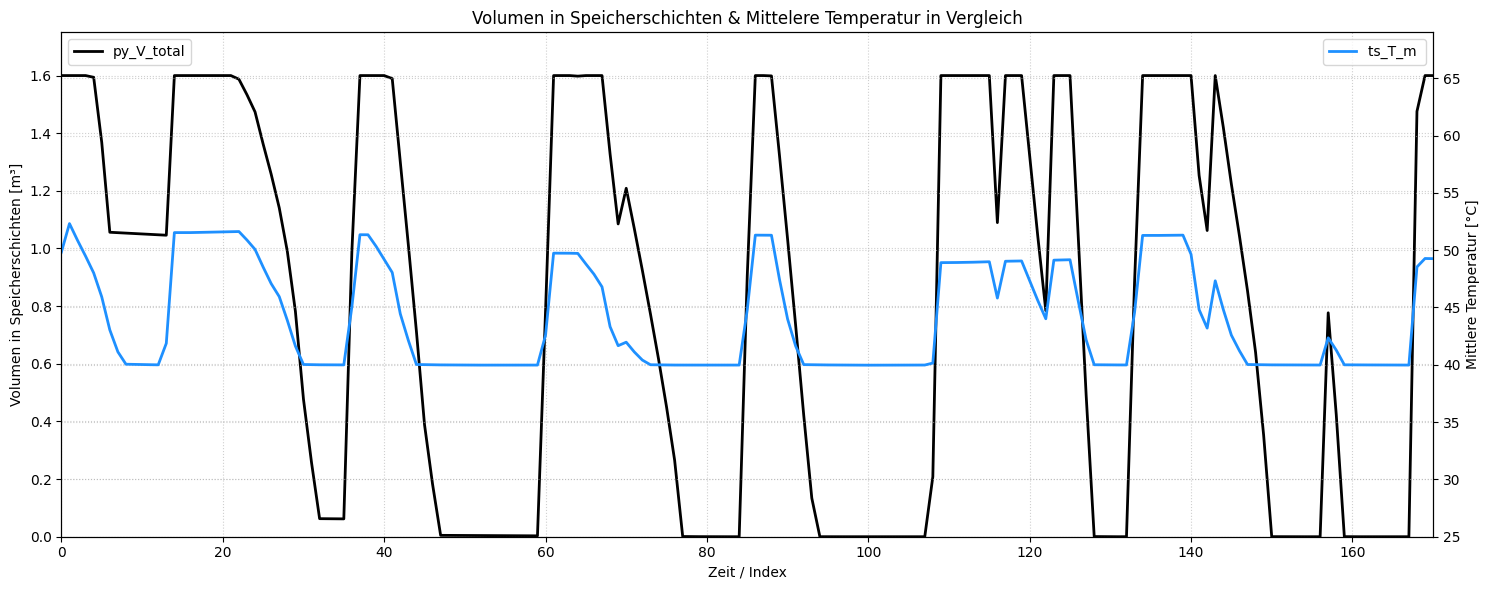

In [32]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot(output_pypsa.index,output_combined_ordered['py_V_total'], label='py_V_total', linewidth=2, color='black')

ax1.set_title('Volumen in Speicherschichten & Mittelere Temperatur in Vergleich')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Volumen in Speicherschichten [m³]')
ax1.set_xlim(0, 170)
ax1.set_ylim(0,1.75) # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Rechte y-Achse: Temperaturen ---
ax2 = ax1.twinx()
ax2.plot(TRNSYSdata.index, TRNSYSdata['ts_T_m'], label='ts_T_m ', linewidth=2, color='dodgerblue')

ax2.set_xlabel('Zeit / Index')
ax2.set_ylabel('Mittlere Temperatur [°C]')
ax2.set_xlim(0, 170)
ax2.set_ylim(25,69) # Beispielhafter Bereich für Temperaturen
ax2.grid(True, linestyle=':', alpha=0.6)

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1, labels1, loc='upper left')
ax2.legend(lines2, labels2, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher/Volumen und Mittlere Temperatur im Vergleich.png')
plt.show()

KeyError: 'py_T_m'

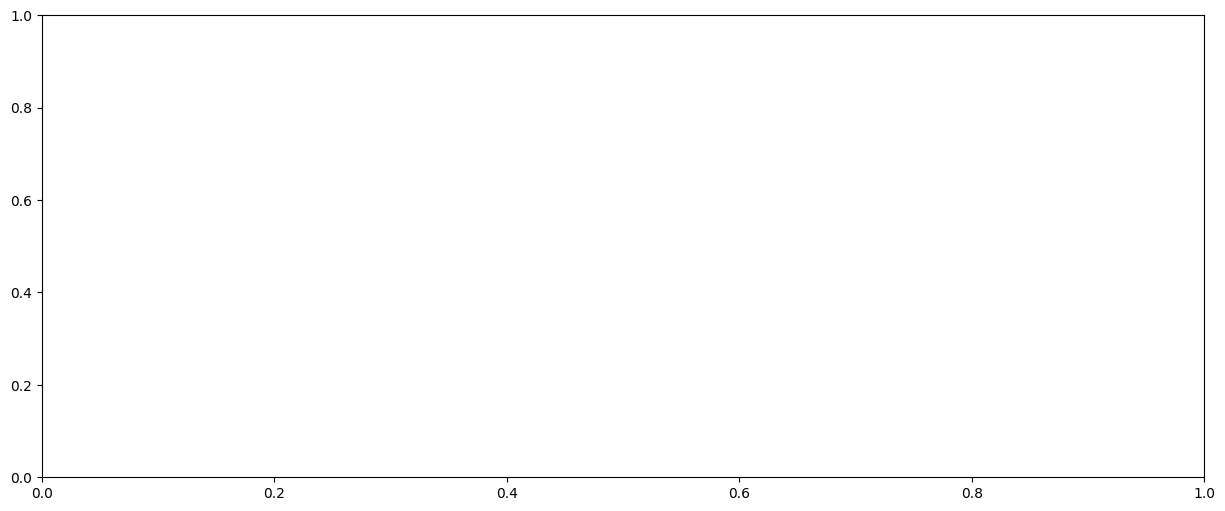

In [39]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plotten der Temperaturen beider Datenquellen auf ax1
ax1.plot(output_pypsa.index, output_pypsa['py_T_m'], label='T_m Python', linewidth=1.5)
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_m'], label='T_m TRNSYS', linewidth=1.5, linestyle='--')

ax1.set_title('Kombinierte Daten: Temperaturen und Leistungen')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Temperatur (°C)')
ax1.set_xlim(0, 170)
ax1.grid(True)

# Rechte y-Achse: Leistungen (in kW)
ax2 = ax1.twinx()

# Plotten der Leistungen aus output_pypsa
ax2.plot(output_pypsa.index, output_pypsa['py_P_heat_total'], label='p_heat Python', color='purple', linestyle='-.', linewidth=1.5)
# Optional: Falls TRNSYS Leistung auch geplottet werden soll (Spaltenname p_heat laut deinem CSV-Beispiel)
if 'p_heat' in TRNSYSdata.columns:
    ax2.plot(TRNSYSdata.index, TRNSYSdata['ts_p_heat'], label='p_heat TRNSYS', color='red', linestyle=':', linewidth=1.5)

ax2.set_ylabel('Leistung (kW)')

# Legende für beide Achsen zusammenführen
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/vergleich_T_m+p_heat.png')
plt.show()

In [40]:
delta_T_m = output_pypsa['py_T_m'] - TRNSYSdata['ts_T_m']

fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(output_pypsa.index, delta_T_m, label='Δ T_m', color='black')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Abweichung [K]')
ax1.tick_params(axis='y')

ax1.axhline(0, color='gray', linewidth=1.2, linestyle='--', alpha=0.5)

limit = abs(delta_T_m).max() * 1.3 if abs(delta_T_m).max() > 0 else 1
ax1.set_ylim(-limit, limit)

ax2 = ax1.twinx() 
ax2.plot(output_combined.index, output_combined.py_P_heat_total, label='P_heat', color='red', alpha=0.6)
ax2.set_ylabel('Leistung [W] / [kW]') 
ax2.tick_params(axis='y')

plt.title('Korrelation: Mittlere Temperaturdifferenz vs. Wärmeleistung', fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.7)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_xlim(0, 170)
plt.tight_layout()
plt.show()

KeyError: 'py_T_m'

In [41]:
correlation_cols = [
    'py_P_heat_total',
    'm_ges',
    'ts_P_heatspace'
]

matrix_df = output_combined[correlation_cols].copy()
matrix_df['delta_T_m'] = delta_T_m

full_corr_matrix = matrix_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(full_corr_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0, 
            vmin=-1, 
            vmax=1, 
            fmt='.2f',
            square=True,
            linewidths=.5)

plt.title('Korrelationsmatrix: Systemschnittstellen vs. delta_T_m', fontsize=14)
plt.tight_layout()
plt.show()

KeyError: "['ts_P_heatspace'] not in index"

In [42]:
plot_data = pd.DataFrame({
    'P_heat': output_combined['py_P_heat_total'],
    'delta_T_m': delta_T_m,
    'index': output_combined.index
}).dropna()

plot_data_nonzero = plot_data[plot_data['P_heat'] != 0].copy()
plot_data_filtered = plot_data_nonzero[plot_data_nonzero['index'] > plot_data['index'].min()]

plt.figure(figsize=(12, 9))

plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Referenz ΔT=0', zorder=1)

x_pos = plot_data_filtered['P_heat'].max() * 0.98
plt.text(x_pos, 0.2, 'PyPSA-Heat > TRNSYS', 
         fontsize=10, color='dodgerblue', fontweight='bold', alpha=0.7, ha='right')
plt.text(x_pos, -0.2, 'TRNSYS > PyPSA-Heat', 
         fontsize=10, color='red', fontweight='bold', alpha=0.7, va='top', ha='right')

plt.plot(plot_data_filtered['P_heat'], plot_data_filtered['delta_T_m'], 
         color='black', alpha=0.1, linewidth=1, zorder=2)

for i in range(len(plot_data_filtered) - 1):
    p1 = plot_data_filtered.iloc[i]
    p2 = plot_data_filtered.iloc[i+1]
    
    if p1['index'] + 1 == p2['index']:
        plt.annotate('', xy=(p2['P_heat'], p2['delta_T_m']), 
                     xytext=(p1['P_heat'], p1['delta_T_m']),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.3),
                     zorder=3)

scatter = plt.scatter(plot_data_filtered['P_heat'], plot_data_filtered['delta_T_m'], 
                      c=plot_data_filtered['index'], cmap='viridis', s=45, alpha=0.8, zorder=4) 

plt.title('Hysterese während Heizvorgängen')
plt.xlabel('Heizleistung P_heat [kW]')
plt.ylabel('Abweichung ΔT_m [K]')
plt.colorbar(scatter, label='Zeitverlauf (Index)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

NameError: name 'delta_T_m' is not defined

In [43]:
kenngroessen = pd.DataFrame({
    'PyPSA-Heat': [
        output_pypsa['py_T_m'].min(),
        output_pypsa['py_T_m'].max(),
        output_pypsa['py_T_m'].max() - output_pypsa['py_T_m'].min(),
    ],
    'TRNSYS': [
        TRNSYSdata['ts_T_m'].min(),
        TRNSYSdata['ts_T_m'].max(),
        TRNSYSdata['ts_T_m'].max() - TRNSYSdata['ts_T_m'].min(),
    ],
}, index=['Minimum [°C]', 'Maximum [°C]', 'Spreizung [K]'])

kenngroessen.plot(kind='bar', figsize=(8, 6), color=['black', 'dodgerblue'])
plt.ylabel('Temperatur [°C] bzw. Spreizung [K]')
plt.title('Minimale/Maximale Speichermitteltemperatur & Temperaturspreizung im Vergleich')
plt.xticks(rotation=0)
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher/MinMaxSpreizung_Vergleich.png')
plt.show()

kenngroessen

KeyError: 'py_T_m'

### Bestimmung der Abweichungen zwischen pypsa_heat und TRYNSIS

#### Mean Absolute Error
The mean absolute error (MAE) is defined as a measure of the average absolute deviation of a model from a reference value. Since deviations are taken as absolute values, the MAE does not indicate whether the model tends to underestimate or overestimate, but only how large the typical deviation is.

Differenz aus jedem Messpunkt (Vorzeichen unwichtig) und dann den Durchschnittswert

In [ ]:
#Berechnung der mittleren absoluten Abweichung (MAE) für jede Schicht

schichten = ["T_m"]  # nur T_m verfügbar: TRNSYS exportiert für den konstanten Temperaturspeicher keine Schichttemperaturen T_1/T_2/T_3
# MAE
abweichung_df = {}

for s in schichten:
    py_col = f"py_{s}"
    ts_col = f"ts_{s}"

    diff = output_combined[py_col] - output_combined[ts_col]
    abweichung_df[s] = np.mean(np.abs(diff))

abweichung_df = pd.DataFrame.from_dict(abweichung_df, orient="index", columns=["MAE [K]"])
abweichung_df

#### RMSE – Root Mean Square Error
Wie MAE, aber durch das Quadrieren werden große Einzelabweichungen überproportional stark gewichtet. RMSE ≥ MAE ist immer der Fall; je größer der Abstand zwischen beiden, desto mehr "Ausreißer" oder ungleichmäßig verteilte Fehler stecken in den Daten.

Differenz aus jedem Messpunkt (Vorzeichen unwichtig), dann Quadriert (größere Abweichung werden sträker bestraft als kleinere) und dann den Durchschnittswert gebildet und dann die Wurzel gezogen

In [ ]:
#Berechnung der mittleren absoluten Abweichung (MAE) für jede Schicht
for s in schichten:
    py_col = f"py_{s}"
    ts_col = f"ts_{s}"

    diff = output_combined[py_col] - output_combined[ts_col]
    abweichung_df.loc[s, "RMSE [K]"] = np.sqrt((diff**2).mean())
    
abweichung_df

####  CV(RMSE) – Coefficient of Variation of RMSE
RMSE normiert auf den Mittelwert – das eigentliche "Haupt-Gütekriterium", weil es Streuungsfehler *und* Normierung in einer Zahl vereint. Werte um 2 % liegen weit unter der ASHRAE-Schwelle von 30 %, sehr gut.

Der RMSE wird durch den Mittelwert geteilt, ergibt einen relativer Wert. Relative Werte sind hier aussagekräftiger als absolute Werte.

In [ ]:
#Berechnung des CV(RMSE/Mean) für jede Schicht
for s in schichten:
    py_col = f"py_{s}"
    ts_col = f"ts_{s}"
    ts_mean = np.mean(output_combined[ts_col])

    abweichung_df.loc[s, "CV(RMSE)[%]"] = abweichung_df.loc[s, "RMSE [K]"] / ts_mean * 100
    
abweichung_df

##### MBE - Mean Bias Error
Mean bias error (MBE) is defined as a measure of the tendency of a model to either underestimate or overestimate a value. A negative MBE indicates underestimation, while a positive MBE indicates overestimation.

Durschnittliche Abweichung aller Messwerte. Sagt aus ob unser System über- oder Unterschätz. In unserem Fall sind pypsa_heat Ergebnisse tendenziell geringer als die von TRYNSIS

In [ ]:
# MBE
for s in schichten:
    py_col = f"py_{s}"
    ts_col = f"ts_{s}"

    diff = output_combined[py_col] - output_combined[ts_col]
    abweichung_df.loc[s, "MBE [K]"] = np.mean(diff)
    
abweichung_df


#### NMBE - Normalized Mean Bias Error

The normalized mean bias error (NMBE) is defined as the mean bias error (MBE) normalized by the mean of the reference values, expressed as a percentage.

MBE / Mittelwert -> erhalten den Wert um wie viel Prozent pypsa_heat unter den TRYNSIS Ergebnissen liegt.

In [ ]:
# NMBE
for s in schichten:
    py_col = f"py_{s}"
    ts_col = f"ts_{s}"

    diff = output_combined[py_col] - output_combined[ts_col]
    ts_mean = np.mean(output_combined[ts_col])
    abweichung_df.loc[s, "NMBE [%]"] = np.mean(diff) / ts_mean * 100
abweichung_df

#### R² 
Es beantwortet wie ähnlich in der Dynamik die beiden Modelle sind. 1 = Perfekte übereinstimmung der Daten. 





In [ ]:
# R²
for s in schichten:
    py_col = f"py_{s}"
    ts_col = f"ts_{s}"

    diff_py_p_mean = output_combined[py_col] - np.mean(output_combined[py_col])
    diff_ts_p_mean = output_combined[ts_col] - np.mean(output_combined[ts_col])
    r_squared = (np.sum(diff_py_p_mean * diff_ts_p_mean) ** 2) / (np.sum(diff_py_p_mean ** 2) * np.sum(diff_ts_p_mean ** 2))
    ts_mean = np.mean(output_combined[ts_col])
    abweichung_df.loc[s, "R²"] = r_squared

abweichung_df

#### MaxAbsDev + Zeitpunkt

In [ ]:
# T_MaxAbsDev
for s in schichten:
    py_col = f"py_{s}"
    ts_col = f"ts_{s}"

    diff = output_combined[py_col] - output_combined[ts_col]
    abs_diff = diff.abs()

    abweichung_df.loc[s, "MaxAbsDev [K]"] = abs_diff.max()
    abweichung_df.loc[s, "T_MaxAbsDev [h]"] = abs_diff.idxmax()

abweichung_df

In [ ]:
abweichung_df.to_excel("Outputs/konstanterTemperaturspeicher/Fehleranalyse_pypsa_trynsis.xlsx", index=True,)